We re-run the embeddings as in Notebook 01, except now filtered to the TFs present in the signaling network from Notebook 03 and the strong perturbations in Notebook 02

In [1]:
filter_perts = True

In [2]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = '1'
os.environ["MKL_NUM_THREADS"] = '1'
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ["VECLIB_MAXIMUM_THREADS"] = '1'
os.environ["NUMEXPR_NUM_THREADS"] = '1'

In [7]:
# load from Notebook 01
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', author + '_tf_activity_all.h5ad'))


# ensure all embedding objects are cleared
del tf_adata.obs['TF_clusters']
tf_adata.uns = {}
for emb_name in ['X_pca', 'X_pls', 'X_umap', 'X_umap_pls']:
    del tf_adata.obsm[emb_name]
    
del tf_adata.varm['PCs']

for obsm_key in ['connectivities', 'distances']:
    del tf_adata.obsp[obsm_key]


cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'


# filter from Notebook 02
if filter_perts:
    pert_strength = pd.read_csv(os.path.join(data_path, 'processed', author + '_pert_strength_quantification.csv'), 
                               index_col = 0)
    strong_perts = set(pert_strength[pert_strength.strong].perturbation)
    strong_perts.add(ctrl_pert)
    tf_adata = tf_adata[tf_adata.obs[pert_col].isin(strong_perts)].copy()



In [8]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Filter for TFs retained in the signaling network:

In [9]:
tf_labels = tf_adata.var.index.unique().tolist()
og_n = len(tf_labels)

included_nodes = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
tf_labels = [tf for tf in tf_labels if tf in included_nodes]
print('{} of {} TFs are present in the signaling network'.format(len(tf_labels), og_n))
tf_adata = tf_adata[:,tf_labels].copy()


380 of 516 TFs are present in the signaling network


Re-run embedding as in Notebook 01 on the filtered features and perturbations:

In [10]:
covariates = [cat_col, pert_col, 'assigned_donor', 'phase']
comparison_metric = 'chance_adjusted_accuracy'

Run embeddings and associated quantifications:

In [12]:
tf_adata, _, cv_df_pca_global_round1 = ls.pc_pipeline(
    adata = tf_adata, 
    pert_ids = tf_adata.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata.obs[cat_col].unique().tolist(),
    n_components = None, # automatically determine
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, 
    run_umap = True, 
    covariate_associations = covariates, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = os.path.join(data_path, 'interim', author + '_latent_association_filtered_pca'), 
    verbose = True,
    n_cores = n_cores, 
    seed = seed,
    embkwrgs = {
        'cluster_data': True, 
        'n_neighbors': 15,
        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        'cluster_col_name': 'TF_clusters',
        'nmi_label': 'condition', 
        
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is z-scored
            'zero_center': False # there are no HVGs so this is by default the behavior
        }    
    }
)

Run dimensionality reductions


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/orcd/pool/

Iterate through leiden resolutions


  0%|                                                     | 0/6 [00:00<?, ?it/s]/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/latent_separation.py:325: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = adata, resolution = res)
100%|█████████████████████████████████████████████| 6/6 [00:07<00:00,  1.29s/it]


Calculate covariate - PC associations
cell_type


...

assigned_donor


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

phase


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

cell_type
ligand
assigned_donor
phase


In [13]:
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

tf_adata, _, cv_df_pls_global_round1 = ls.pls_da_pipeline(
    adata = tf_adata, 
    pert_ids = tf_adata.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata.obs[cat_col].unique().tolist(),
    n_components = None,
    control_confounders = None, 
    assess_pls_fit = True,
    pert_col = pert_col,
    cat_col = cat_col,
    separate_by = 'perturbation',
    pls_kwargs = None, 
    component_selection_kwargs = csw,
    assessment_kwargs = assessment_kwargs,
    covariate_associations = covariates,
    per_component_association = False, 
    global_component_association = True,
    run_umap = True,
    file_prefix = os.path.join(data_path, 'interim', author + '_latent_association_filtered_pls'),
    verbose = True,
    n_cores = n_cores,
    seed = seed
)
pls_model = tf_adata.uns['pls']['pls_mod']

Fit PLS Model
Iterate through components for PLS selection of number of components


100%|███████████████████████████████████████████| 25/25 [03:56<00:00,  9.47s/it]


Begin assessment of final model fit


  0%|                                                   | 0/100 [00:00<?, ?it/s]/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprec

Calculate covariate - PLS associations
cell_type
ligand
assigned_donor
phase
cell_type
ligand


PLS Assessment Permutations:   0%|                      | 0/100 [00:58<?, ?it/s]


assigned_donor
phase
Get UMAP


-----PCA-----
Elbow selection via variance explained identified 12 as the optimal number of PCA components
-----PLS-----
Elbow selection via accuracy identified 6 as the optimal number of PLS components
The model fit has a R2Y of 0.66
The model fit has a Q2Y of 0.66, with p-value 0.010
The model fit has a accuracy of 0.90


''

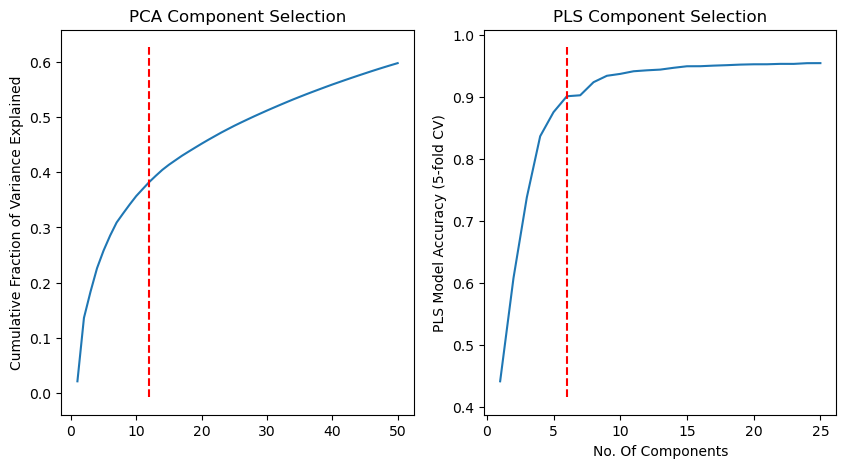

In [14]:
print('-----PCA-----')
n_pca = tf_adata.uns['pca']['pca_rank']
print('Elbow selection via variance explained identified {} as the optimal number of PCA components'.format(n_pca))

print('-----PLS-----')
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        if metric_vals['pval'] is None:
            print('The model fit has a {} of {:.2f}'.format(
                metric_type, metric_vals['value']
            ))
        else:
            print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
                metric_type, metric_vals['value'], metric_vals['pval']
            ))
            
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

i = 0
cumulative_variance_ratio = np.cumsum(tf_adata.uns['pca']['variance_ratio']) #adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(cumulative_variance_ratio))) + 1
sns.lineplot(x = pcs, y = cumulative_variance_ratio, ax = ax[i])

ymin, ymax = ax[i].get_ylim()
ax[i].vlines(x = n_pca, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
             color = 'red', linestyle = '--')
ax[i].set_title('PCA Component Selection')
ax[i].set_ylabel('Cumulative Fraction of Variance Explained')



i = 1
sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[i])
ymin, ymax = ax[i].get_ylim()
ax[i].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax[i].set_xlabel('No. Of Components')
ax[i].set_ylabel('PLS Model Accuracy (5-fold CV)')
# ax[i].legend()
ax[i].set_title('PLS Component Selection')
;

''

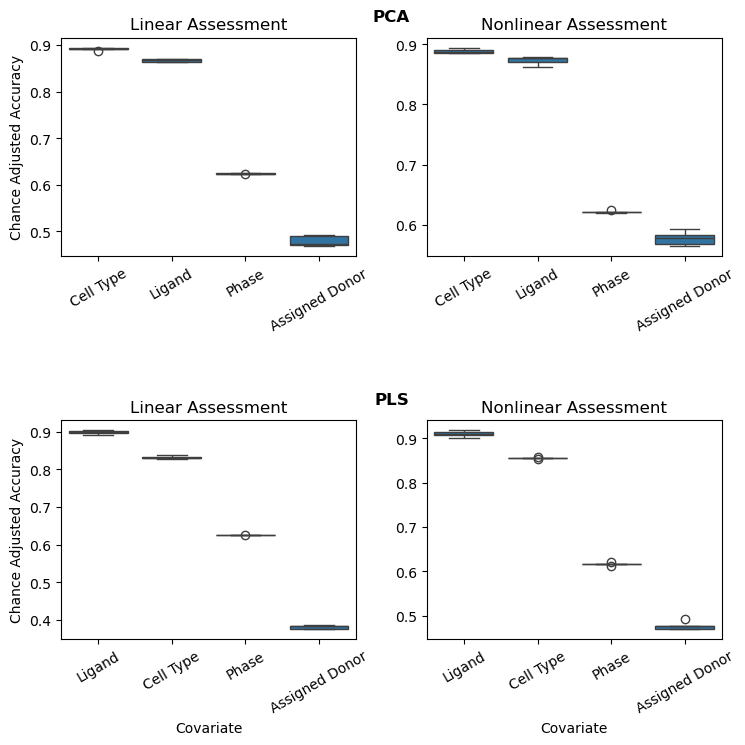

In [16]:
cv_globals = {'PCA': cv_df_pca_global_round1, 
             'PLS': cv_df_pls_global_round1}
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (8, 8))



for i, (ls_type, cv_global) in enumerate(cv_globals.items()):
    row_ax = fig.add_subplot(2, 1, i + 1, frame_on=False)
    row_ax.set_title(ls_type, fontsize=12, fontweight='bold', pad=12)
    row_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    row_ax.grid(False)
    for j, model_type in enumerate(cv_global.model_type.unique()):
        viz_df = cv_global[cv_global.model_type == model_type]
        viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
        viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
        viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
        x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
        viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
        viz_df.covariate = viz_df.covariate.apply(lambda x: ' '.join([x_.capitalize() for x_ in x[:-1].split('_')]))

        sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i,j])
        for label in ax[i,j].get_xticklabels():
            label.set_rotation(30)
                    
        
        ax[i,j].set_xlabel('Covariate') if i == 1 else ax[i,j].set_xlabel('')
        ax[i,j].set_ylabel('Chance Adjusted Accuracy') if j == 0 else ax[i,j].set_ylabel('')
        ax[i,j].set_title(model_type.capitalize() + ' Assessment') #if i == 0 else ax[i,j].set_title('')
    
fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_filtered_ls_quantification.png'), 
            dpi=300, bbox_inches="tight")

;

We can see now that ligand has become a much stronger relative covariate in the latent spaces, more comparable to that of cell type, and beyond biological phase or batch as compared to Notebook 01. 

''

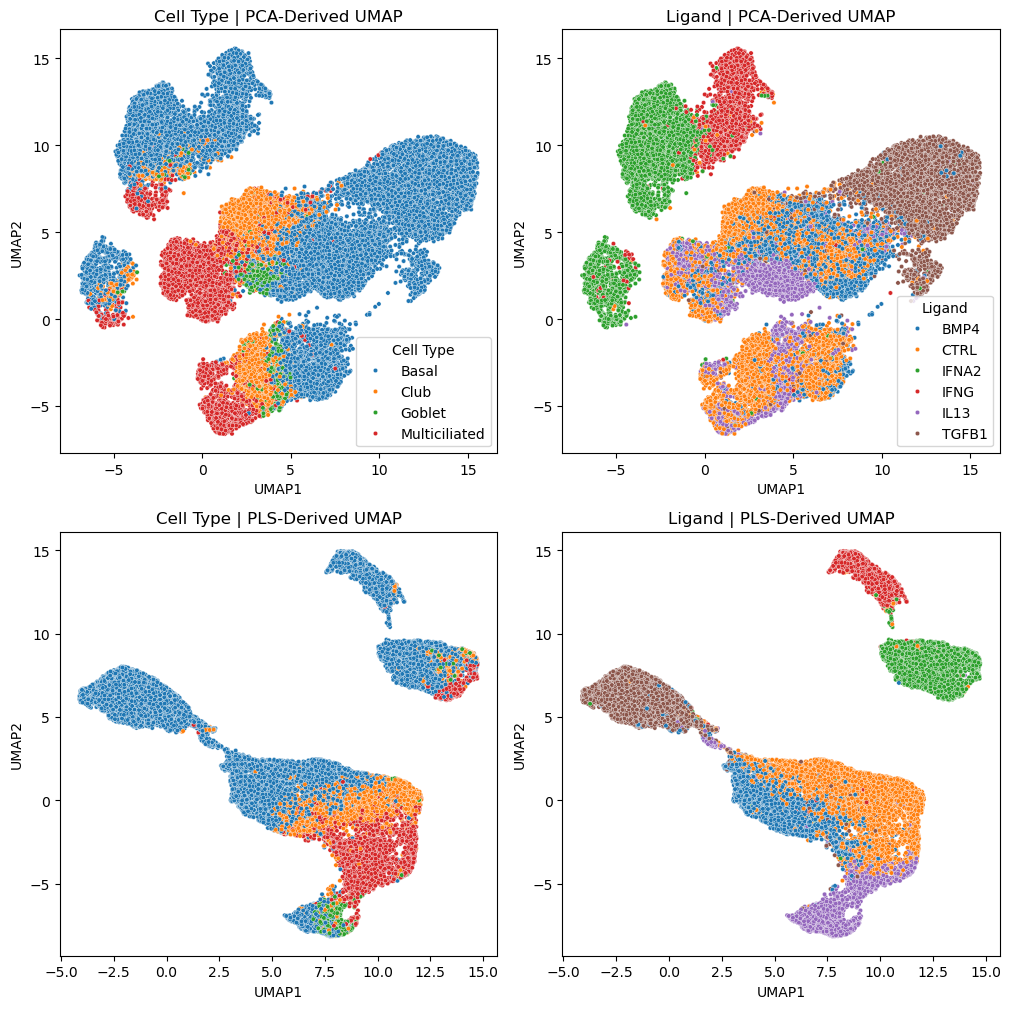

In [29]:
ncols, nrows = 2,2
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'umap': 'PCA-Derived UMAP', 
         'umap_pls': 'PLS-Derived UMAP'}

for i, latent_label in enumerate(['umap', 'umap_pls']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'UMAP'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None and i != 0:
            ax[i,j].legend_.remove()
        else:
            title = ax[i, j].get_legend().get_title().get_text()
            ax[i, j].legend(title=' '.join([c.capitalize() for c in title.split('_')]))
            
        ax[i,j].set_title('{} | {}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')]), 
            ll_map[latent_label]))

fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_filtered_umap_visualization.png'), 
            dpi=300, bbox_inches="tight")
;

''

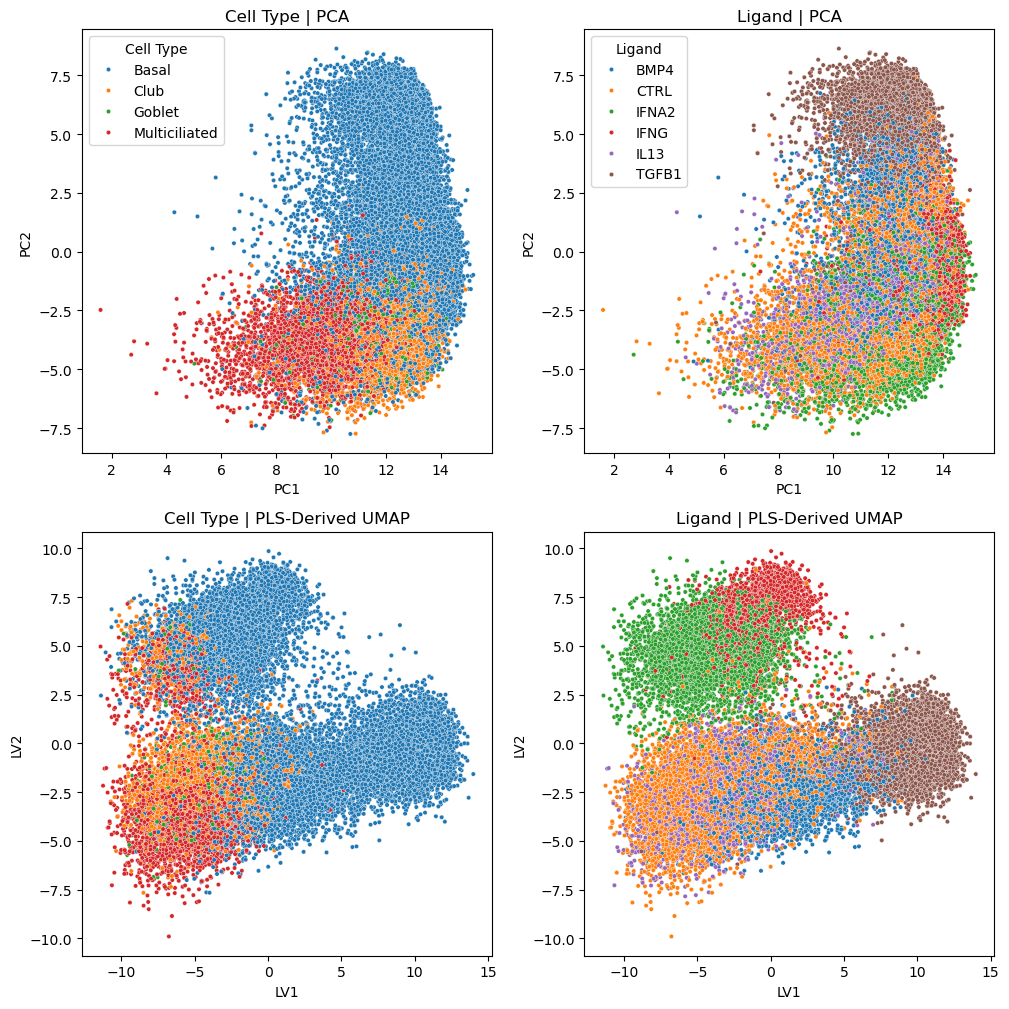

In [50]:
ncols, nrows = 2,2
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'pca': 'PCA', 
         'pls': 'PLS-Derived UMAP'}

for i, latent_label in enumerate(['pca', 'pls']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'PC' if latent_label == 'pca' else 'LV'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None and i != 0:
            ax[i,j].legend_.remove()
        else:
            title = ax[i, j].get_legend().get_title().get_text()
            ax[i, j].legend(title=' '.join([c.capitalize() for c in title.split('_')]))
            
        ax[i,j].set_title('{} | {}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')]), 
            ll_map[latent_label]))

fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_filtered_pca_pls_visualization.png'), 
            dpi=300, bbox_inches="tight")
;

In [31]:
io.write_tfad(tf_adata, os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))